In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#Model 1: Moving Average
Moving_Average = pd.read_csv('/content/MovingAverage.csv')
Moving_Average['Date'] =  pd.to_datetime(Moving_Average['Date'])
Moving_Average=Moving_Average.set_index('Date')

Closing_Prices = pd.read_csv('/content/final_closing_prices_pivot.csv')
Closing_Prices['Date'] =  pd.to_datetime(Closing_Prices['Date'])
Closing_Prices=Closing_Prices.set_index('Date')


#Model 2: Linear Regression
LR_Predicted_Prices = pd.read_csv('/content/LR_Predicted_Prices.csv')
LR_Predicted_Prices['Date'] =  pd.to_datetime(LR_Predicted_Prices['Date'])
LR_Predicted_Prices=LR_Predicted_Prices.set_index('Date')

LR_Actual_Prices = pd.read_csv('/content/LR_Actual_Prices.csv')
LR_Actual_Prices['Date'] =  pd.to_datetime(LR_Actual_Prices['Date'])
LR_Actual_Prices=LR_Actual_Prices.set_index('Date')


#Model 3: LSTM
PCA_Predicted_Prices = pd.read_csv('/content/PCA_Predicted_Prices1.csv')
PCA_Predicted_Prices['Date'] =  pd.to_datetime(PCA_Predicted_Prices['Date'])
PCA_Predicted_Prices=PCA_Predicted_Prices.set_index('Date')

PCA_Actual_Prices = pd.read_csv('/content/PCA_Actual_Prices1.csv')
PCA_Actual_Prices['Date'] =  pd.to_datetime(PCA_Actual_Prices['Date'])
PCA_Actual_Prices=PCA_Actual_Prices.set_index('Date')

In [ ]:
#Computing Log Returns
PCA_Predicted_Returns = PCA_Predicted_Prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]
PCA_Actual_Returns = PCA_Actual_Prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]

LR_Predicted_Returns = LR_Predicted_Prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]
LR_Actual_Returns = LR_Actual_Prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]

Closing_Prices_Returns = Closing_Prices.apply(lambda x: np.log(x) - np.log(x.shift(1))).iloc[1:]

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
from sklearn.metrics import mean_squared_error
mean_squared_error(PCA_Actual_Prices, PCA_Predicted_Prices)

73328.06933542408

In [ ]:
#Mean Returns function
def mean_returns(df, length):
  mu = df.sum(axis = 0)/length
  return mu

In [ ]:
from datetime import timedelta
from dateutil.parser import parse

def monthdelta(date, delta):
    m, y = (date.month+delta) % 12, date.year + ((date.month)+delta-1) // 12
    if not m: m = 12
    d = min(date.day, [31,
        29 if y%4==0 and not y%400==0 else 28,31,30,31,30,31,31,30,31,30,31][m-1])
    new_date = (date.replace(day=d,month=m, year=y))
    return parse(new_date.strftime('%Y-%m-%d'))


#This part of the code takes in a dataset and splits it into datasets w/ lookback months and forward looking months
def windowGenerator (dataframe, lookback, horizon,
                    step, cummulative = False):

#takes pandas dataframe with DatetimeIndex

    if cummulative:
        c = lookback
        step = horizon

    initial = min(dataframe.index)
    windows = []
    horizons = []

    while initial <= monthdelta(max(dataframe.index), -lookback):
        windowStart = initial
        windowEnd = monthdelta(windowStart, lookback)
        if cummulative:
            windowStart = min(dataframe.index)
            windowEnd = monthdelta(windowStart, c) + timedelta(days=1)
            c += horizon
        horizonStart = windowEnd + timedelta(days=1)
        horizonEnd = monthdelta(horizonStart, horizon)

        lookbackWindow = dataframe[windowStart:windowEnd]
        horizonWindow = dataframe[horizonStart:horizonEnd]

        windows.append(lookbackWindow)
        horizons.append(horizonWindow)

        initial = monthdelta(initial, step)

    return windows, horizons

In [ ]:
from scipy.optimize import minimize, Bounds, LinearConstraint
from numpy.linalg import norm

def actual_return(actual_returns, w):
  actual_returns = actual_returns
  mean_return = mean_returns(actual_returns, actual_returns.shape[0])
  actual_covariance = actual_returns.cov()

  portfolio_returns = mean_return.T.dot(w)
  portfolio_variance = w.T.dot(actual_covariance).dot(w)
  return portfolio_returns, portfolio_variance


#Input entire predicted returns df, actual returns df, starting date
def scipy_opt(predicted_returns, actual_returns, lam1, lam2):
  mean_return = mean_returns(predicted_returns, predicted_returns.shape[0])
  predicted_covariance = predicted_returns.cov()

  #Cost Function
  def f(w):
    return -(mean_return.T.dot(w) - lam1*(w.T.dot(predicted_covariance).dot(w)) + lam2*norm(w, ord=1))
  #out custom maximises

  #Bounds of Weights
  opt_bounds = Bounds(0, 1)

  #Equality Constraints
  def h(w):
    return sum(w) - 1

  #Constraints Dictionary
  cons = ({
      'type' : 'eq',
      'fun' : lambda w: h(w)
  })

  #Solver
  sol = minimize(f,
                 x0 = np.ones(mean_return.shape[0]),
                 constraints = cons,
                 bounds = opt_bounds,
                 options = {'disp': False},
                 tol=10e-10)


  #Predicted Results
  w = sol.x
  predicted_portfolio_returns = w.dot(mean_return)
  portfolio_STD = w.T.dot(predicted_covariance).dot(w)

  #Actual Results
  portfolio_actual_returns, portfolio_actual_variance = actual_return(actual_returns, w)
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)

  ret_dict = {'weights' : w,
              'predicted_returns' : predicted_portfolio_returns,
              'predicted_variance' : portfolio_STD,
              'actual_returns' : portfolio_actual_returns,
              'actual_variance' : portfolio_actual_variance,
              'sharpe_ratio': sharpe_ratio}

  return ret_dict

In [ ]:
#Moving average only needs to look at historical mean returns to make a prediction for the future. It
#essentially follows the trend of our lookback window
MA_act_windows, MA_act_horizons = windowGenerator(Closing_Prices_Returns, 12, 1, 1)

In [ ]:
MA_scipy_returns= []
MA_scipy_variance = []
MA_scipy_SR = []

# Testing on 5 years of data
for i in range(len(MA_act_horizons)-72,len(MA_act_horizons)-12):
  #Scipy optimize results
  scipy = scipy_opt(MA_act_windows[i], MA_act_horizons[i], .5, 2)
  MA_scipy_returns.append(scipy['actual_returns'])
  MA_scipy_variance.append(scipy['actual_variance'])
  MA_scipy_SR.append(scipy['sharpe_ratio'])
  # print("Month " + str(i) + " complete")

/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio

In [ ]:
timestamps = []
for i in range(len(MA_act_horizons)-72,len(MA_act_horizons)-12):
  time = MA_act_horizons[i].index[-1]
  timestamps.append(time)

MA_Portfolio_Returns = pd.DataFrame(data = np.array([MA_scipy_returns,MA_scipy_variance,MA_scipy_SR]).T, columns = ['Returns', 'Variance', 'Sharpe Ratio'], index=timestamps)
MA_Portfolio_Returns.index.rename('Date')

MA_Portfolio_Returns.to_csv('MA_Portfolio_Returns.csv')

cp: cannot create regular file 'drive/My Drive/Machine Learning Project/ML Section Exports': No such file or directory


In [ ]:
MA_Portfolio_Returns.head()

,Returns,Variance,Sharpe Ratio
2019-08-02,-0.001471,0.000352,-inf
2019-08-30,0.000375,0.000324,inf
2019-10-02,-0.001865,0.000366,-inf
2019-11-01,-0.001070,0.000180,-inf
2019-12-02,0.003094,0.000219,inf


In [ ]:
LR_pred_windows, LR_pred_horizons = windowGenerator(LR_Predicted_Returns, 12, 1, 1)
LR_act_windows, LR_act_horizons = windowGenerator(LR_Actual_Returns, 12, 1, 1)

In [ ]:
LR_scipy_returns= []
LR_scipy_variance = []
LR_scipy_SR = []

#Testing on 5 years of data
for i in range(len(LR_act_horizons)-72,len(LR_act_horizons)-12):
  #Scipy optimize results
  scipy = scipy_opt(LR_pred_horizons[i], LR_act_horizons[i], .5, 2)
  LR_scipy_returns.append(scipy['actual_returns'])
  LR_scipy_variance.append(scipy['actual_variance'])
  LR_scipy_SR.append(scipy['sharpe_ratio'])
  # print("Month " + str(i) + " complete")

/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)
/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio

In [ ]:
timestamps = []
for i in range(len(LR_act_horizons)-72,len(LR_act_horizons)-12):
  time = LR_act_horizons[i].index[-1]
  timestamps.append(time)

LR_Portfolio_Returns = pd.DataFrame(data = np.array([LR_scipy_returns,LR_scipy_variance,LR_scipy_SR]).T, columns = ['Returns', 'Variance', 'Sharpe Ratio'], index=timestamps)


In [ ]:
LR_Portfolio_Returns.to_csv('LR_Portfolio_Returns.csv')

In [ ]:
LSTM_pred_windows, LSTM_pred_horizons = windowGenerator(PCA_Predicted_Returns,12,1,1)
LSTM_act_windows, LSTM_act_horizons = windowGenerator(PCA_Actual_Returns,12,1,1)

In [ ]:
len(LSTM_pred_horizons)

202

In [ ]:
scipy_returns= []
scipy_variance = []
scipy_SR = []


for i in range(len(LSTM_act_horizons)-60,len(LSTM_act_horizons)):
  #Scipy optimize results
  scipy = scipy_opt(LSTM_pred_horizons[i], LSTM_act_horizons[i], .5, 2)
  scipy_returns.append(scipy['actual_returns'])
  scipy_variance.append(scipy['actual_variance'])
  scipy_SR.append(scipy['sharpe_ratio'])
  print("Month " + str(i) + " complete")

Month 142 complete


/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)


Month 143 complete
Month 144 complete
Month 145 complete
Month 146 complete
Month 147 complete
Month 148 complete
Month 149 complete
Month 150 complete
Month 151 complete
Month 152 complete


/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)


Month 153 complete
Month 154 complete
Month 155 complete
Month 156 complete
Month 157 complete
Month 158 complete
Month 159 complete
Month 160 complete
Month 161 complete
Month 162 complete
Month 163 complete
Month 164 complete


...

Month 174 complete
Month 175 complete
Month 176 complete
Month 177 complete
Month 178 complete
Month 179 complete
Month 180 complete
Month 181 complete
Month 182 complete
Month 183 complete


/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)


Month 184 complete
Month 185 complete
Month 186 complete
Month 187 complete
Month 188 complete
Month 189 complete
Month 190 complete
Month 191 complete
Month 192 complete
Month 193 complete


/tmp/ipython-input-6-3500931047.py:53: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe_ratio = portfolio_actual_returns/np.std(portfolio_actual_variance)


Month 194 complete
Month 195 complete
Month 196 complete
Month 197 complete
Month 198 complete
Month 199 complete
Month 200 complete
Month 201 complete


In [ ]:
timestamps = []
for i in range(len(LSTM_act_horizons)-60,len(LSTM_act_horizons)):
  time = LSTM_act_horizons[i].index[0]
  timestamps.append(time)


LSTM_Portfolio_Returns = pd.DataFrame(data = np.array([scipy_returns,scipy_variance,scipy_SR]).T, columns = ['Returns', 'Variance', 'Sharpe Ratio'], index=timestamps)

LSTM_Portfolio_Returns.to_csv('LSTM_Portfolio_Returns.csv')

In [ ]:
timestamps

[Timestamp('2019-05-06 00:00:00'),
 Timestamp('2019-06-04 00:00:00'),
 Timestamp('2019-07-05 00:00:00'),
 Timestamp('2019-08-05 00:00:00'),
 Timestamp('2019-09-04 00:00:00'),
 Timestamp('2019-10-04 00:00:00'),
 Timestamp('2019-11-04 00:00:00'),
 Timestamp('2019-12-04 00:00:00'),
 Timestamp('2020-01-06 00:00:00'),
 Timestamp('2020-02-04 00:00:00'),
 Timestamp('2020-03-04 00:00:00'),
 Timestamp('2020-04-06 00:00:00'),
 Timestamp('2020-05-04 00:00:00'),
 Timestamp('2020-06-04 00:00:00'),
 Timestamp('2020-07-06 00:00:00'),
 Timestamp('2020-08-04 00:00:00'),
 Timestamp('2020-09-04 00:00:00'),
 Timestamp('2020-10-05 00:00:00'),
 Timestamp('2020-11-04 00:00:00'),
 Timestamp('2020-12-04 00:00:00'),
 Timestamp('2021-01-04 00:00:00'),
 Timestamp('2021-02-04 00:00:00'),
 Timestamp('2021-03-04 00:00:00'),
 Timestamp('2021-04-05 00:00:00'),
 Timestamp('2021-05-04 00:00:00'),
 Timestamp('2021-06-04 00:00:00'),
 Timestamp('2021-07-06 00:00:00'),
 Timestamp('2021-08-04 00:00:00'),
 Timestamp('2021-09-

In [ ]:
LSTM_Portfolio_Returns.head()

,Returns,Variance,Sharpe Ratio
2019-05-06,0.000299,0.000203,inf
2019-06-04,0.006523,0.000545,inf
2019-07-05,0.000392,0.000152,inf
2019-08-05,0.001648,0.000119,inf
2019-09-04,0.000392,0.000374,inf


## Diagnostics
The calculation for seeing how much the portfolio grows in dollar terms:


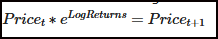


Given $100, our equity graph shows how much our portfolio value increase (or decreases)

In [ ]:
import math
MA_equity = [100]
LR_equity = [100]
LSTM_equity = [100]

#This is the calculation for the for seeing how much the portfolio grows
for i in range(1,60):
  MA_equity.append(MA_equity[i-1]* math.exp(MA_scipy_returns[i]))
  LR_equity.append(LR_equity[i-1]* math.exp(LR_scipy_returns[i]))
  LSTM_equity.append(LSTM_equity[i-1]* math.exp(scipy_returns[i]))

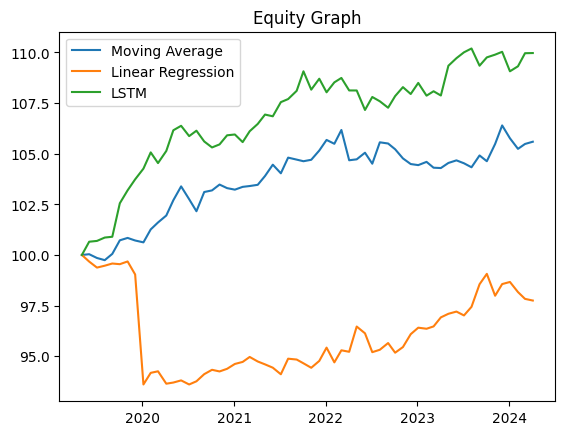

In [ ]:
plt.plot(timestamps, MA_equity,  label = "Moving Average")
plt.plot(timestamps, LR_equity, label = "Linear Regression")
plt.plot(timestamps, LSTM_equity, label = "LSTM")
plt.title("Equity Graph")
plt.legend()
plt.show();

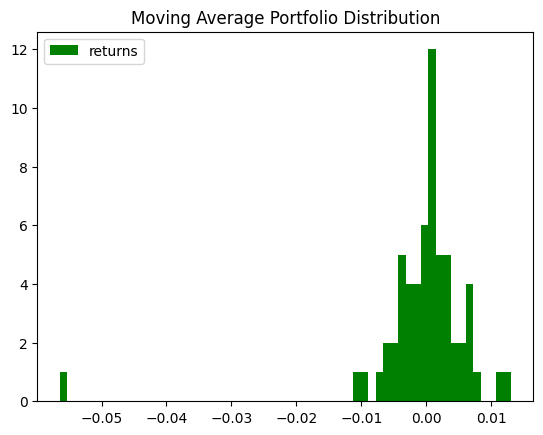

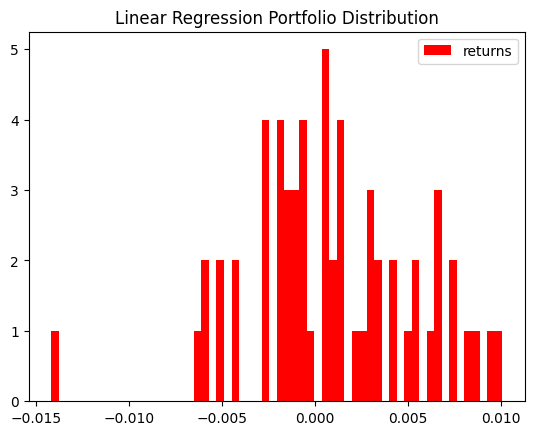

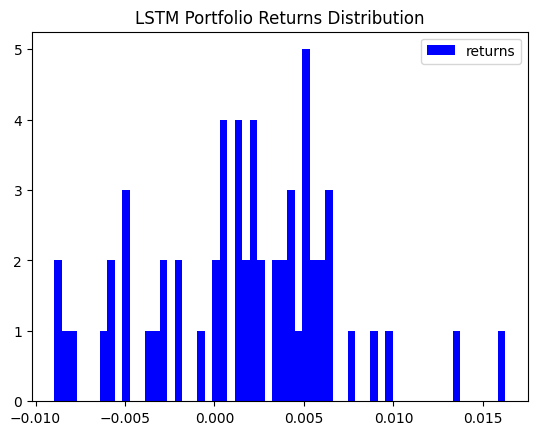

In [ ]:
plt.hist(LR_scipy_returns, bins = 60, label = 'returns', alpha = 1, color = 'green')
plt.title("Moving Average Portfolio Distribution")
plt.legend()
plt.show();
plt.hist(MA_scipy_returns, bins = 60, label = 'returns', alpha = 1, color = 'red')
plt.title("Linear Regression Portfolio Distribution")
plt.legend()
plt.show();
plt.hist(scipy_returns, bins = 60, label = 'returns', alpha = 1, color = 'blue')
plt.title("LSTM Portfolio Returns Distribution")
plt.legend()
plt.show();

In [ ]:
print("Moving Average Ending Equity: " , MA_equity[-1])
print("Linear Regression Ending Equity: " , LR_equity[-1])
print("LSTM Ending Equity" , LSTM_equity[-1])

Moving Average Ending Equity:  105.59270734856025
Linear Regression Ending Equity:  97.74993435456473
LSTM Ending Equity 109.9715619577069


In [ ]:
import math
def metrics(returns):
  sharpe = returns.mean() / returns.std()
  annualized_sharpe = sharpe.item() / math.sqrt(252)

  stdev = returns.std()
  annualized_vol = stdev.item() / math.sqrt(252)


  return {"Annualized Sharpe Ratio": annualized_sharpe,
          "Annualized Volatility": annualized_vol}

In [ ]:
#Annualized info for Moving Average
metrics(np.array(MA_scipy_returns))

{'Annualized Sharpe Ratio': 0.012428812668935828,
 'Annualized Volatility': 0.00028175459560945764}

In [ ]:
#Annualized info for Linear Regression
metrics(np.array(LR_scipy_returns))

{'Annualized Sharpe Ratio': -0.0032602315077715762,
 'Annualized Volatility': 0.0005402592101370854}

In [ ]:
#Annualized info for LSTM
metrics(np.array(scipy_returns))

{'Annualized Sharpe Ratio': 0.01942298883359709,
 'Annualized Volatility': 0.00032468170595014963}